In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns
from pathlib import Path

## Part A -- **Data preparation**

In [2]:
home=Path.cwd().parent

In [3]:
df0=pd.read_csv(home/"data/raw/fear_greed_index.csv")
df1=pd.read_csv(home/'data/raw/historical_data.csv')

In [4]:
df0.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [5]:
df1.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [6]:
df0.describe ()

,timestamp,value
count,2.644000e+03,2644.000000
mean,1.631899e+09,46.981089
std,6.597967e+07,21.827680
min,1.517463e+09,5.000000
25%,1.574811e+09,28.000000
50%,1.631900e+09,46.000000
75%,1.688989e+09,66.000000
max,1.746164e+09,95.000000


In [7]:
print(df0.isnull().sum())
df0.shape

timestamp         0
value             0
classification    0
date              0
dtype: int64


(2644, 4)

In [8]:
print(df1.shape)
df1.isnull().sum()

(211224, 16)


Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

In [9]:
df1.duplicated().sum()

np.int64(0)

In [10]:
df0.duplicated().sum()

np.int64(0)

In [11]:
df1['win'] = (df1['Closed PnL'] > 0).astype(int)

In [12]:
df1['Timestamp IST']= pd.to_datetime(df1['Timestamp IST'],dayfirst=True)

In [13]:
df1['date']=df1['Timestamp IST'].dt.strftime('%Y-%m-%d')

In [14]:
df0['date']=pd.to_datetime(df0['date']).dt.date
df1['date']=pd.to_datetime(df1['date']).dt.date

In [15]:
df1.head(2)

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,win,date
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,0,2024-12-02
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,0,2024-12-02


In [16]:
metrics = df1.groupby(['Account', 'date']).agg({
    'Closed PnL': 'sum',# all profits/losses of that day
    'Size USD': 'mean', # Average trade size
    'Trade ID': 'count', #number of trades
    'win': 'mean' # % of profitable trades 
}).reset_index()
metrics.rename(columns={'symbol':'num_trades'},inplace =True)

In [17]:
metrics.isnull().sum()

Account       0
date          0
Closed PnL    0
Size USD      0
Trade ID      0
win           0
dtype: int64

In [18]:
metrics.rename(columns={
    'Closed PnL': 'daily_pnl', 
    'Size USD': 'avg_trade_size',
    'Trade ID': 'num_trades',
    'win': 'win_rate'
}, inplace=True)

In [19]:
metrics.describe()

,daily_pnl,avg_trade_size,num_trades,win_rate
count,2341.000000,2341.000000,2341.000000,2341.000000
mean,4398.530091,6989.515321,90.228108,0.359926
std,28415.938999,21538.691665,214.611751,0.343601
min,-358963.139984,0.000000,1.000000,0.000000
25%,0.000000,695.250952,9.000000,0.000000
50%,207.983482,1914.000000,29.000000,0.318182
75%,1842.839943,7051.005833,80.000000,0.608000
max,533974.662903,844654.190000,4083.000000,1.000000


In [20]:
metrics.isnull().sum()

Account           0
date              0
daily_pnl         0
avg_trade_size    0
num_trades        0
win_rate          0
dtype: int64

In [21]:
metrics.head()

,Account,date,daily_pnl,avg_trade_size,num_trades,win_rate
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-11,0.0,5089.718249,177,0.000000
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-17,0.0,7976.664412,68,0.000000
2,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-18,0.0,23734.500000,40,0.000000
3,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-22,-21227.0,28186.666667,12,0.000000
4,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-26,1603.1,17248.148148,27,0.444444


In [22]:
df0.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [23]:
df1.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,win,date
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,0,2024-12-02
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,0,2024-12-02
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,0,2024-12-02
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,0,2024-12-02
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,0,2024-12-02


## Merging dataset

In [24]:
merged = pd.merge(
    metrics,
    df0,
    left_on='date',
    right_on='date',
    how='left'
)

In [25]:
merged.sample(5)

,Account,date,daily_pnl,avg_trade_size,num_trades,win_rate,timestamp,value,classification
2063,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,2025-03-20,824.540280,1638.542667,30,0.333333,1.742449e+09,49.0,Neutral
2153,0xbd5fead7180a9c139fa51a103cb6a2ce86ddb5c3,2024-12-24,0.000000,1070.000000,10,0.000000,1.735018e+09,73.0,Greed
1650,0x8477e447846c758f5a675856001ea72298fd9cb5,2025-04-11,19.202581,553.040820,61,0.196721,1.744349e+09,25.0,Fear
1441,0x8170715b3b381dffb7062c0298972d4727a0a63b,2025-04-27,-99.444041,768.452500,12,0.000000,1.745732e+09,61.0,Greed
1145,0x72c6a4624e1dffa724e6d00d64ceae698af892a0,2025-01-26,262.950000,1671.996182,55,0.290909,1.737869e+09,73.0,Greed


In [26]:
merged.isnull().sum()

Account           0
date              0
daily_pnl         0
avg_trade_size    0
num_trades        0
win_rate          0
timestamp         1
value             1
classification    1
dtype: int64

In [27]:
merged=merged.dropna(subset=['classification'])

In [28]:
merged=merged.copy()

# Part B -- Analysis

In [29]:
merged.groupby('classification')['daily_pnl'].describe()

,count,mean,std,min,25%,50%,75%,max
classification,,,,,,,,
Extreme Fear,160.0,4619.439053,29534.839183,-77308.420095,0.0,218.377399,3381.323773,229058.684298
Extreme Greed,526.0,5161.922644,27496.863832,-132271.000000,0.0,418.319862,2385.426442,449328.107544
Fear,630.0,5328.818161,31659.771538,-108604.496278,0.0,107.892532,1807.148049,533974.662903
Greed,648.0,3318.100730,30599.040173,-358963.139984,0.0,158.214922,1319.220865,375620.270243
Neutral,376.0,3438.618818,17447.863645,-113601.020138,0.0,167.551743,1321.966347,194499.072534


In [30]:
trade_median=merged.groupby('classification')['num_trades'].median().round(2)
trade_median
trade_mean=merged.groupby('classification')['num_trades'].mean().round(2)
trade_mean_median = pd.DataFrame({
    'mean': trade_mean,
    'median': trade_median
})
print(trade_mean)
print(trade_median)

classification
Extreme Fear     133.75
Extreme Greed     76.03
Fear              98.15
Greed             77.63
Neutral          100.23
Name: num_trades, dtype: float64
classification
Extreme Fear     50.5
Extreme Greed    31.5
Fear             26.0
Greed            25.0
Neutral          29.5
Name: num_trades, dtype: float64


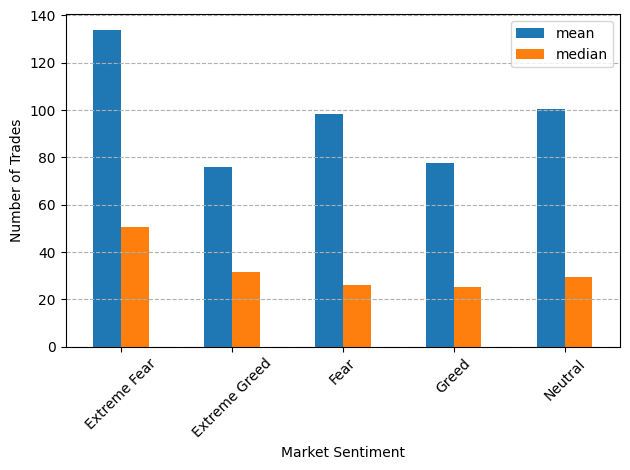

In [31]:
trade_mean_median.plot(kind='bar')
plt.grid(axis='y',ls='--')
plt.ylabel("Number of Trades")
plt.xlabel("Market Sentiment")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Activity insights from the graph

The gap between mean and median trade frequency is largest during Extreme Fear, indicating that a small subset of traders engage in disproportionately high trading activity, while most remain less active. This suggests uneven and potentially reactive behavior under high market stress.

In [32]:
trade_size_mean=merged.groupby('classification')['avg_trade_size'].mean().round(2)
trade_size_median=merged.groupby('classification')['avg_trade_size'].median().round(2)
trade_s_mean_median=pd.DataFrame({
    'mean':trade_size_mean,
    'median':trade_size_median,
})
print('mean trade size\n',trade_size_mean)
print('\nmedian trade size')
trade_size_median

mean trade size
 classification
Extreme Fear     6773.46
Extreme Greed    5371.64
Fear             8975.93
Greed            6427.87
Neutral          6963.69
Name: avg_trade_size, dtype: float64

median trade size


classification
Extreme Fear     2315.63
Extreme Greed    2003.48
Fear             1752.68
Greed            2052.53
Neutral          1704.41
Name: avg_trade_size, dtype: float64

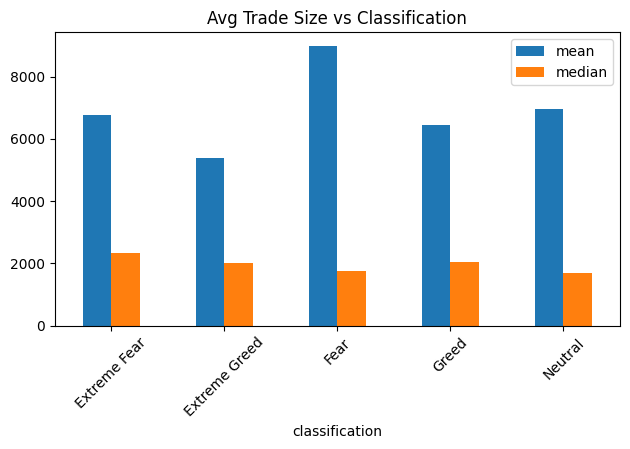

In [33]:
trade_s_mean_median.plot(kind='bar')
plt.title ('Avg Trade Size vs Classification')
plt.tight_layout()
plt.xticks(rotation=45)
plt.show()

## Trade size insights from the above graph

**Fear**--> A small subset of traders take very large positions during Fear periods, while most traders remain relatively conservative -->(outliers )  
**Extreme Fear** --> During Extreme Fear, traders show more consistent position sizing, suggesting broader participation in risk-taking.  
**Greed** --> In Greed conditions, traders exhibit more stable and controlled position sizing, indicating less erratic behavior.  


In [34]:
merged['trader_type'] = merged['num_trades'].apply(
    lambda x: 'high_freq' if x > merged['num_trades'].median() else 'low_freq'
)
class_trade=merged.groupby(['classification','trader_type'])['daily_pnl'].median().round(2)
class_trade

classification  trader_type
Extreme Fear    high_freq       632.30
                low_freq          0.00
Extreme Greed   high_freq      1522.28
                low_freq          9.15
Fear            high_freq       842.08
                low_freq          0.29
Greed           high_freq       901.87
                low_freq          0.00
Neutral         high_freq       712.89
                low_freq          2.39
Name: daily_pnl, dtype: float64

In [35]:
merged['trader_type'].value_counts()

trader_type
low_freq     1174
high_freq    1166
Name: count, dtype: int64

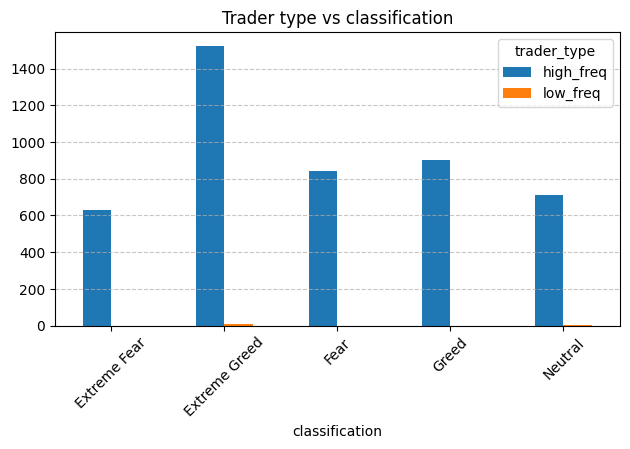

In [36]:
class_trade.unstack().plot(kind='bar')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.title('Trader type vs classification')
plt.tight_layout()
plt.xticks(rotation =45)
plt.show()


## Trader type vs classification insights from the above plot

High-frequency traders achieve their highest median PnL during Extreme Greed conditions, while performance during Fear periods is comparatively lower. This suggests that active trading strategies are more effective in strong trend-driven markets than in volatile or uncertain conditions.

In [37]:
pnl_mean=merged.groupby('classification')['daily_pnl'].mean().round(2)
pnl_mean
pnl_median=merged.groupby('classification')['daily_pnl'].median().round(2)
pnl_mean_median=pd.DataFrame({
    'mean':pnl_mean,
    'median':pnl_median
})
print(pnl_mean)
pnl_median


classification
Extreme Fear     4619.44
Extreme Greed    5161.92
Fear             5328.82
Greed            3318.10
Neutral          3438.62
Name: daily_pnl, dtype: float64


classification
Extreme Fear     218.38
Extreme Greed    418.32
Fear             107.89
Greed            158.21
Neutral          167.55
Name: daily_pnl, dtype: float64

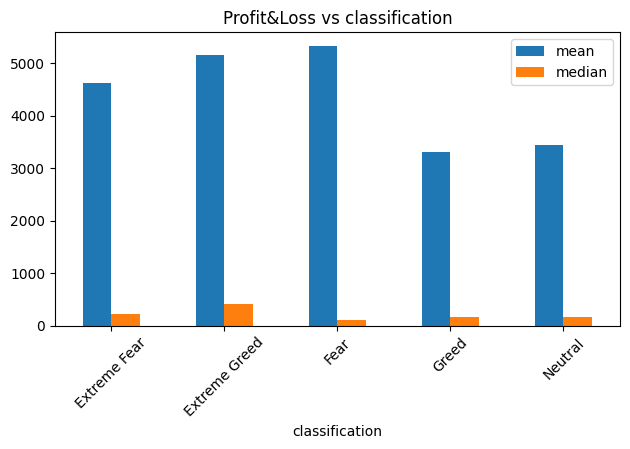

In [38]:
pnl_mean_median.plot(kind='bar')
plt.title('Profit&Loss vs classification')
plt.tight_layout()
plt.xticks(rotation =45)
plt.show()

### Daily PnL vs classification as shown in the chart
High-frequency traders perform best during Extreme Greed conditions, indicating that active strategies benefit more from strong market trends than from volatile Fear periods.

## Rules of thumb

**Strategy 1** :  Exploit trend-driven markets  
Increase trading activity during Extreme Greed conditions, as high-frequency traders achieve the highest median profitability in this regime. This suggests that active strategies are more effective in strong, trend-driven markets.

**Strategy 2** :Avoid overtrading in Fear  
Reduce trading frequency and avoid aggressive position sizing during Fear periods, as increased activity does not translate into consistent profitability and gains are concentrated among a few traders.

**Strategy 3** : Avoid low-frequency strategy  
Avoid low-frequency trading approaches, as infrequent participation consistently results in negligible returns across all sentiment regimes. Maintaining consistent engagement is critical for capturing market opportunities

In [39]:
pip freeze > requirements.txt

Note: you may need to restart the kernel to use updated packages.
